### Load Packages

In [368]:
using LinearAlgebra
using Random
using JuMP, MosekTools, ECOS
using Statistics
using Printf
using PyPlot
using Colors
using Noise

### Include files

In [369]:
core_path = "../../src/core/"
module_path = "../../src/quad3dofcage/"

# Include base core files
include(core_path * "globals.jl")
include(core_path * "structs.jl")

# Include module files
include(module_path * "params.jl")
include(module_path * "scenarios.jl")
include(module_path * "prob_opt.jl")
include(module_path * "prob_scp.jl")
include(module_path * "prob_ddto_feas.jl")
include(module_path * "prob_ddtoscp_feas.jl")
include(module_path * "dynamics.jl")
include(module_path * "initial_guess.jl")

# Include utility files (dependent on module file definitions)
include(core_path * "disc.jl")
include(core_path * "utils.jl")
include(core_path * "utils_ddto.jl")
include(core_path * "utils_ddtoscp.jl")
;

### Solve & Simulate

In [370]:
# ..:: Setup ::..
params = Params()
scenario_toy2!(params)

# ..:: Execute solver sequence ::..
@time begin
    @time begin
        # ..:: Solve for independently-optimal solutions to each target ::..
        scp_solutions = solve_decoupled_scp_tree(params)
        scp_costs = CVector(zeros(params.n_targs))
        for k = 1:params.n_targs
            scp_costs[k] = scp_solutions[k].cost
        end
        println("\n Solve time for generating optimal solutions to each target:")
    end

    # @time begin
    #     # ..:: Solve for DDTO branching solutions to ALL targets ::..
    #     ddtoscp_solutions = solve_ddtoscp_tree(params, scp_costs, deepcopy(scp_solutions))
    #     println("\n Solve time for generating DDTO branch solutions to all targets:")
    # end
    # println("\n Solve time for the full DDTO solution stack:")
end
# ddtoscp_solutions = extract_target_trajectories(params, ddtoscp_solutions)

# ..:: Port decoupled SCP solutions to `BranchSolution` objects for type conformance ::..
scp_solutions_ = Vector{BranchSolution}(undef,params.n_targs)
for j=1:params.n_targs
    scp_solutions_[j] = BranchSolution(scp_solutions[j],-1,-1)
end
scp_solutions = scp_solutions_

# # Identify shared states (deferrable segment of DDTO)
# ϵ = 1e-6
# t_shared = CVector(undef,0)
# x_shared = CMatrix(undef,params.n,0)
# u_shared = CMatrix(undef,params.m,0)
# for k = 1:min(params.N_targs...)
#     shared_state = false
#     for j1 = 1:params.n_targs
#         for j2 = j1:params.n_targs
#             if norm(solutions[j1].sol.x[:,k] - solutions[j2].sol.x[:,k]) < ϵ
#                 t_shared = [t_shared;solutions[j1].sol.t[k]]
#                 x_shared = hcat(x_shared, solutions[j1].sol.x[k])
#                 u_shared = hcat(u_shared, solutions[j1].sol.u[k])
#                 shared_state = true
#                 break
#             end
#         end
#         if shared_state
#             break
#         end
#     end
# end
# defer_solutions = Vector{BranchSolution}(undef, 1)
# defer_solutions[1] = BranchSolution(t_shared,x_shared,u_shared,-1)

# ..:: Simulate each target solution from I.C. to T.C.
@time begin
    dynamics = (t,x,sol) -> params.A_c*x + params.B_c*optimal_controller(t,sol.t,sol.u) + params.p_c
    scp_simulations = simulate_cont(scp_solutions, dynamics)
    # ddtoscp_simulations = simulate_cont(ddtoscp_solutions, params.z0, dynamics)
    # defer_simulations = simulate_cont(defer_solutions, params.z0, dynamics)
    println("\n Solve time for RK4 simulation:")
end

# ..:: Post-processing ::..
@time begin
    # ddtoscp_solutions   = process_solutions(ddtoscp_solutions)
    # ddtoscp_simulations = process_solutions(ddtoscp_simulations)
    scp_solutions       = process_solutions(scp_solutions)
    scp_simulations     = process_solutions(scp_simulations)
    # defer_solutions     = process_solutions(defer_solutions)
    # defer_simulations   = process_solutions(defer_simulations)
    println("\n Solve time for post-processing:")
end
;

82.53733107151066


=== Decoupled SCP solutions for each target ===


   SCP Iter:  1 | Status: Feasible | μ_ctrl_pen = -2.75e-11 | μ_obs_pen = 0.00e+00 | η_pen = 1.88e+00


1.1403769771129466

   SCP Iter:  2 | Status: Feasible | μ_ctrl_pen = 9.98e+00 | μ_obs_pen = 0.00e+00 | η_pen = 1.07e+00


...

   SCP Iter:  9 | Status: Feasible | μ_ctrl_pen = 2.21e-01 | μ_obs_pen = 0.00e+00 | η_pen = 2.41e+01


48.577610570695875

   SCP Iter: 10 | Status: Feasible | μ_ctrl_pen = 4.40e+00 | μ_obs_pen = 0.00e+00 | η_pen = 2.20e+01


Target: 3, Cost: 44040536.261

 Solve time for generating optimal solutions to each target:
  2.723182 seconds (4.15 M allocations: 675.735 MiB, 4.07% gc time, 12.61% compilation time)
  2.723250 seconds (4.15 M allocations: 675.738 MiB, 4.07% gc time, 12.61% compilation time)



 Solve time for RK4 simulation:
  0.158215 seconds (552.14 k allocations: 37.434 MiB, 97.45% compilation time)

 Solve time for post-processing:
  0.000379 seconds (3.86 k allocations: 440.117 KiB)


### Plots

In [371]:
include(module_path * "plots.jl")
set_fonts()
set_fonts()
PyPlot.close("all")
pygui(false)
;

#### Decoupled SCP Plots

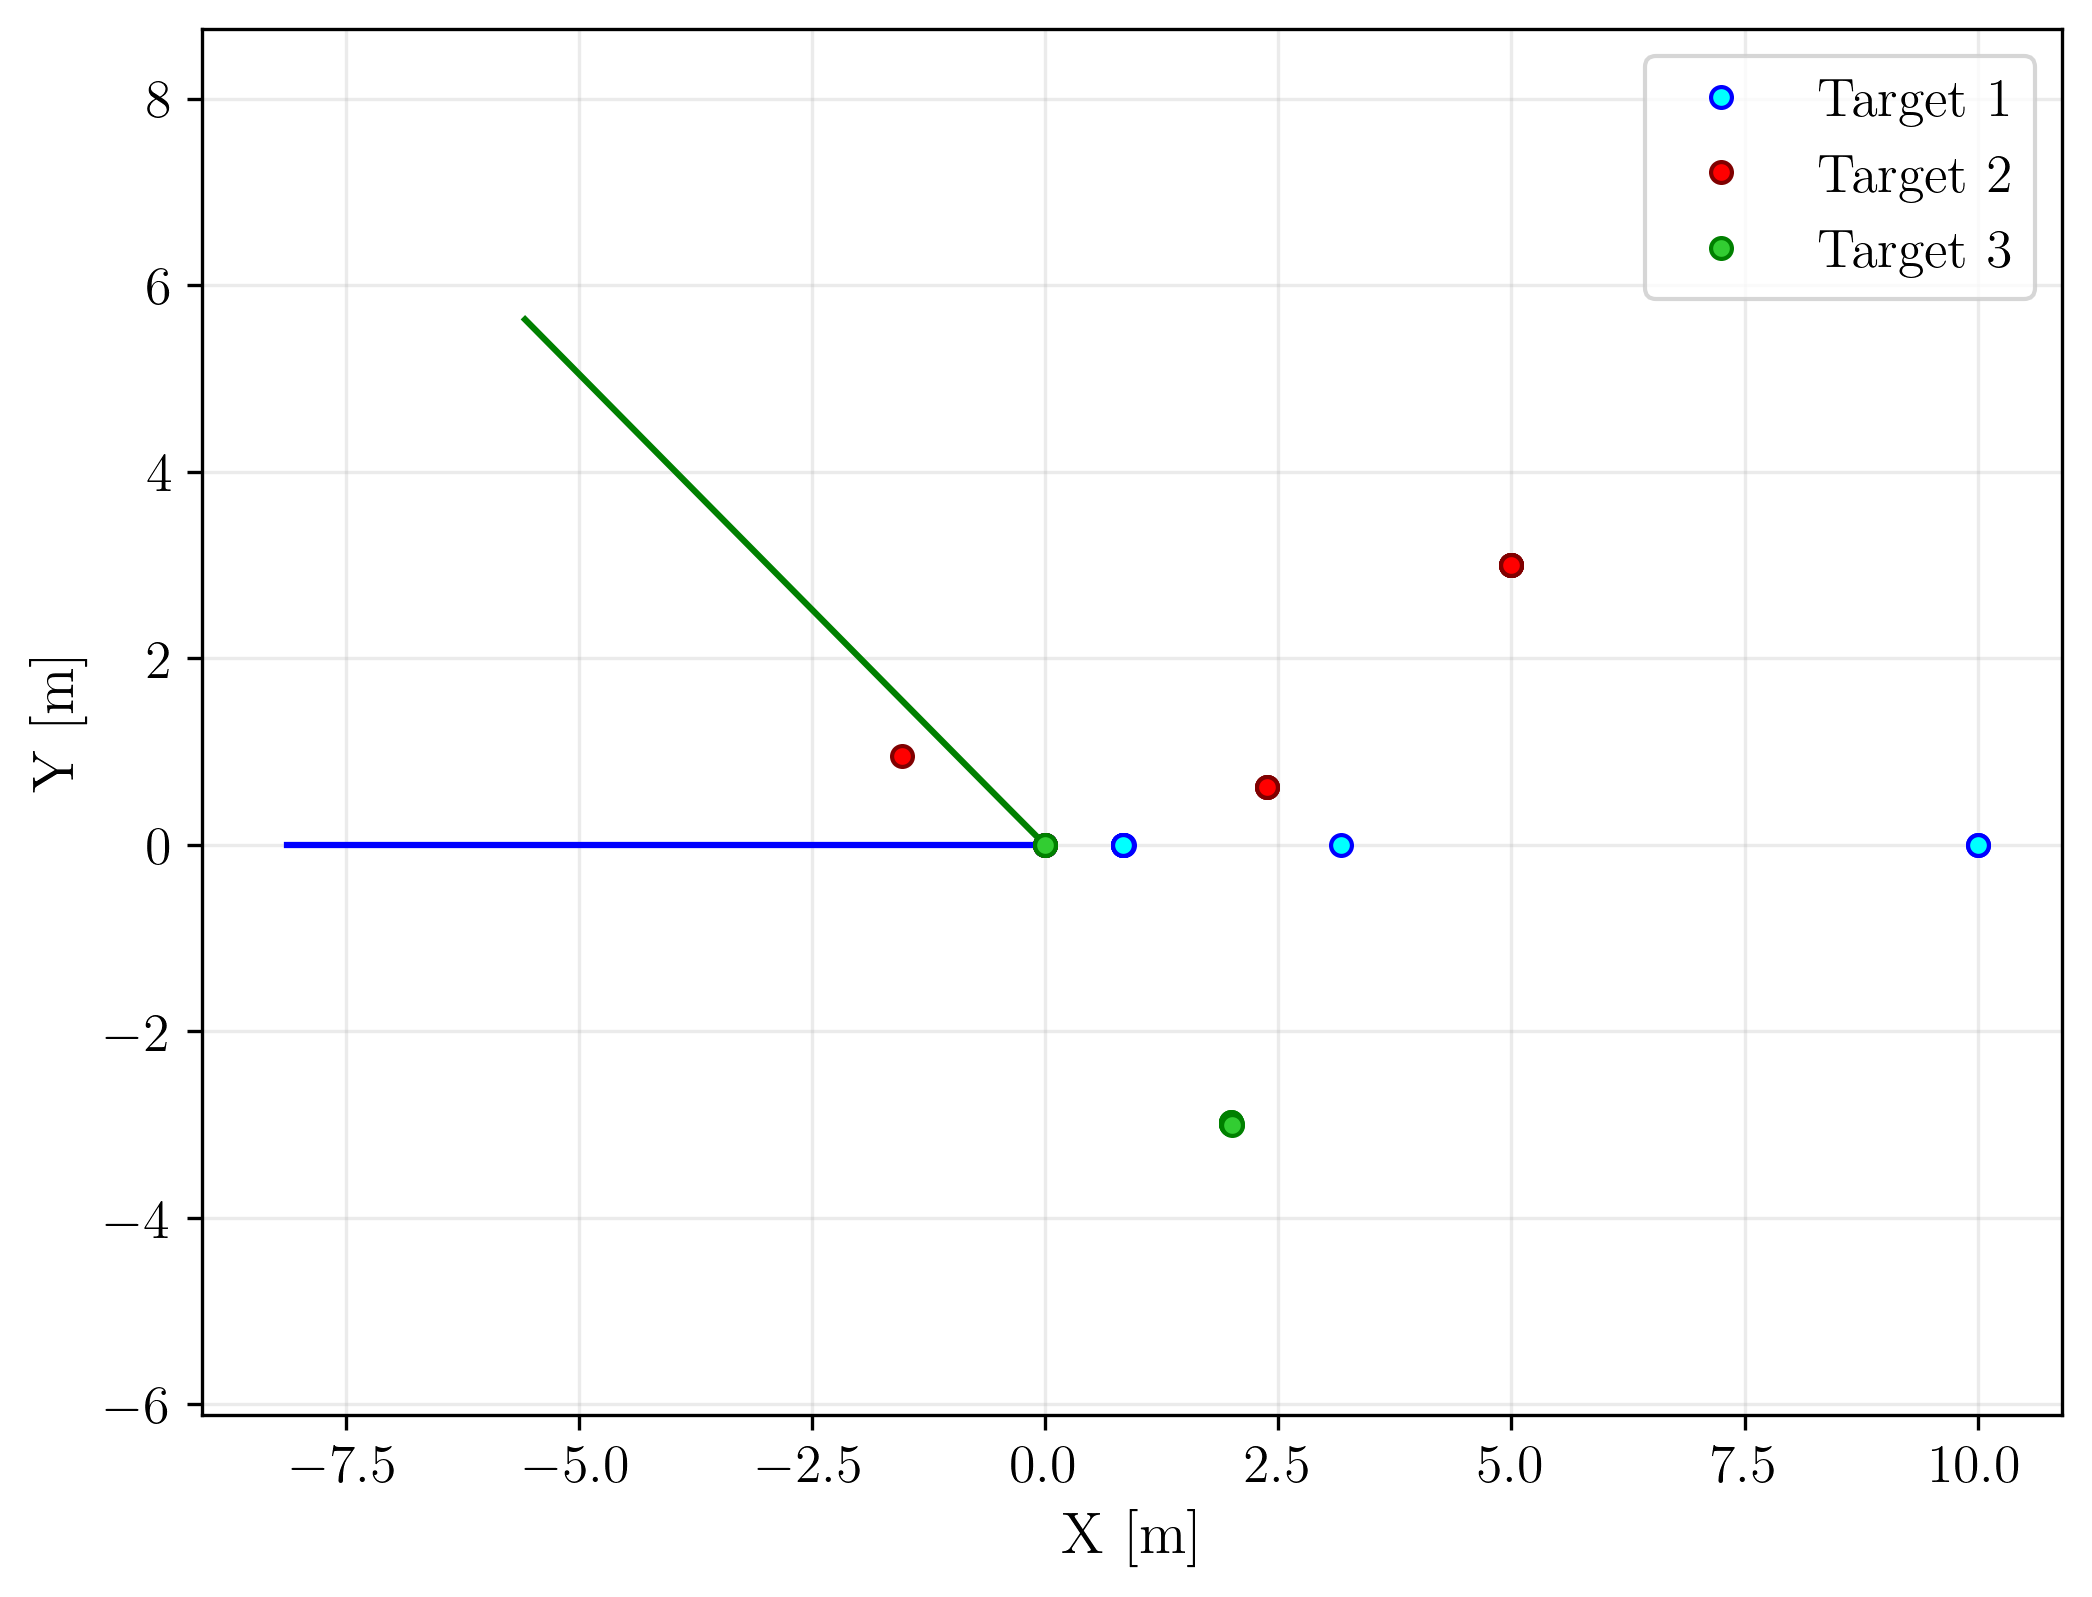

In [372]:
plot_parametric_trajectories(
    params, 
    scp_solutions, 
    scp_simulations;
    display_obstacles=true,
    fname="decoupled_scp_solutions")
gcf()

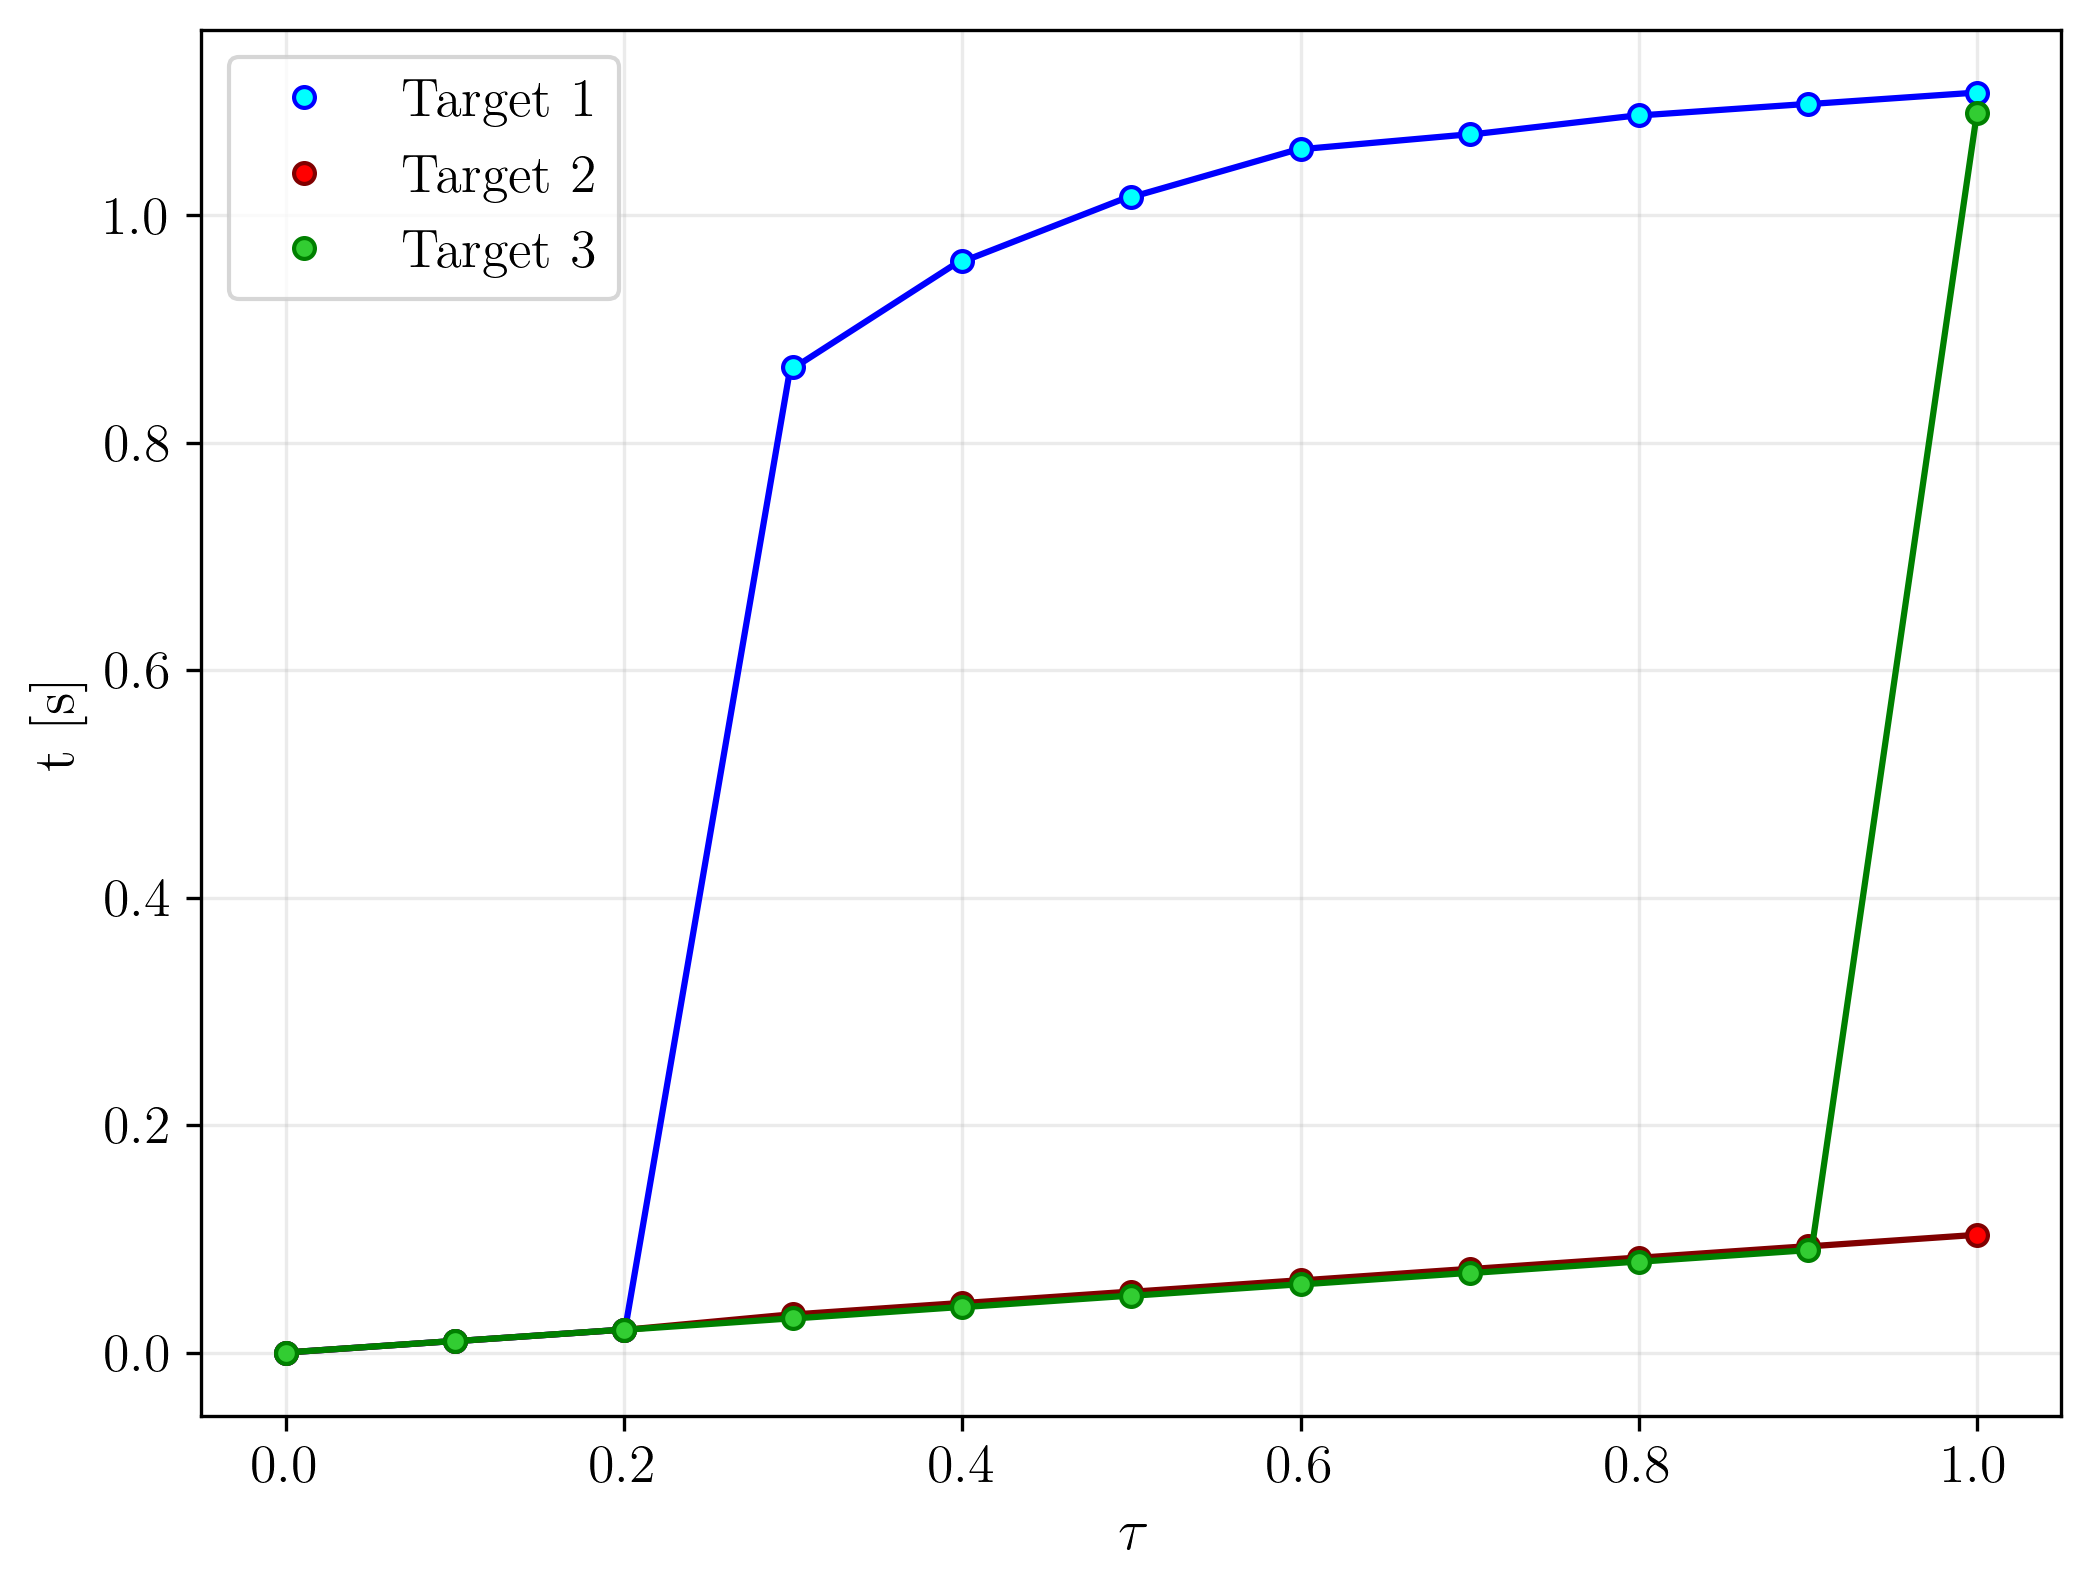

In [373]:
plot_time_dilation(
    params, 
    scp_solutions, 
    scp_simulations;
    fname="plot_time_dilation")
gcf()

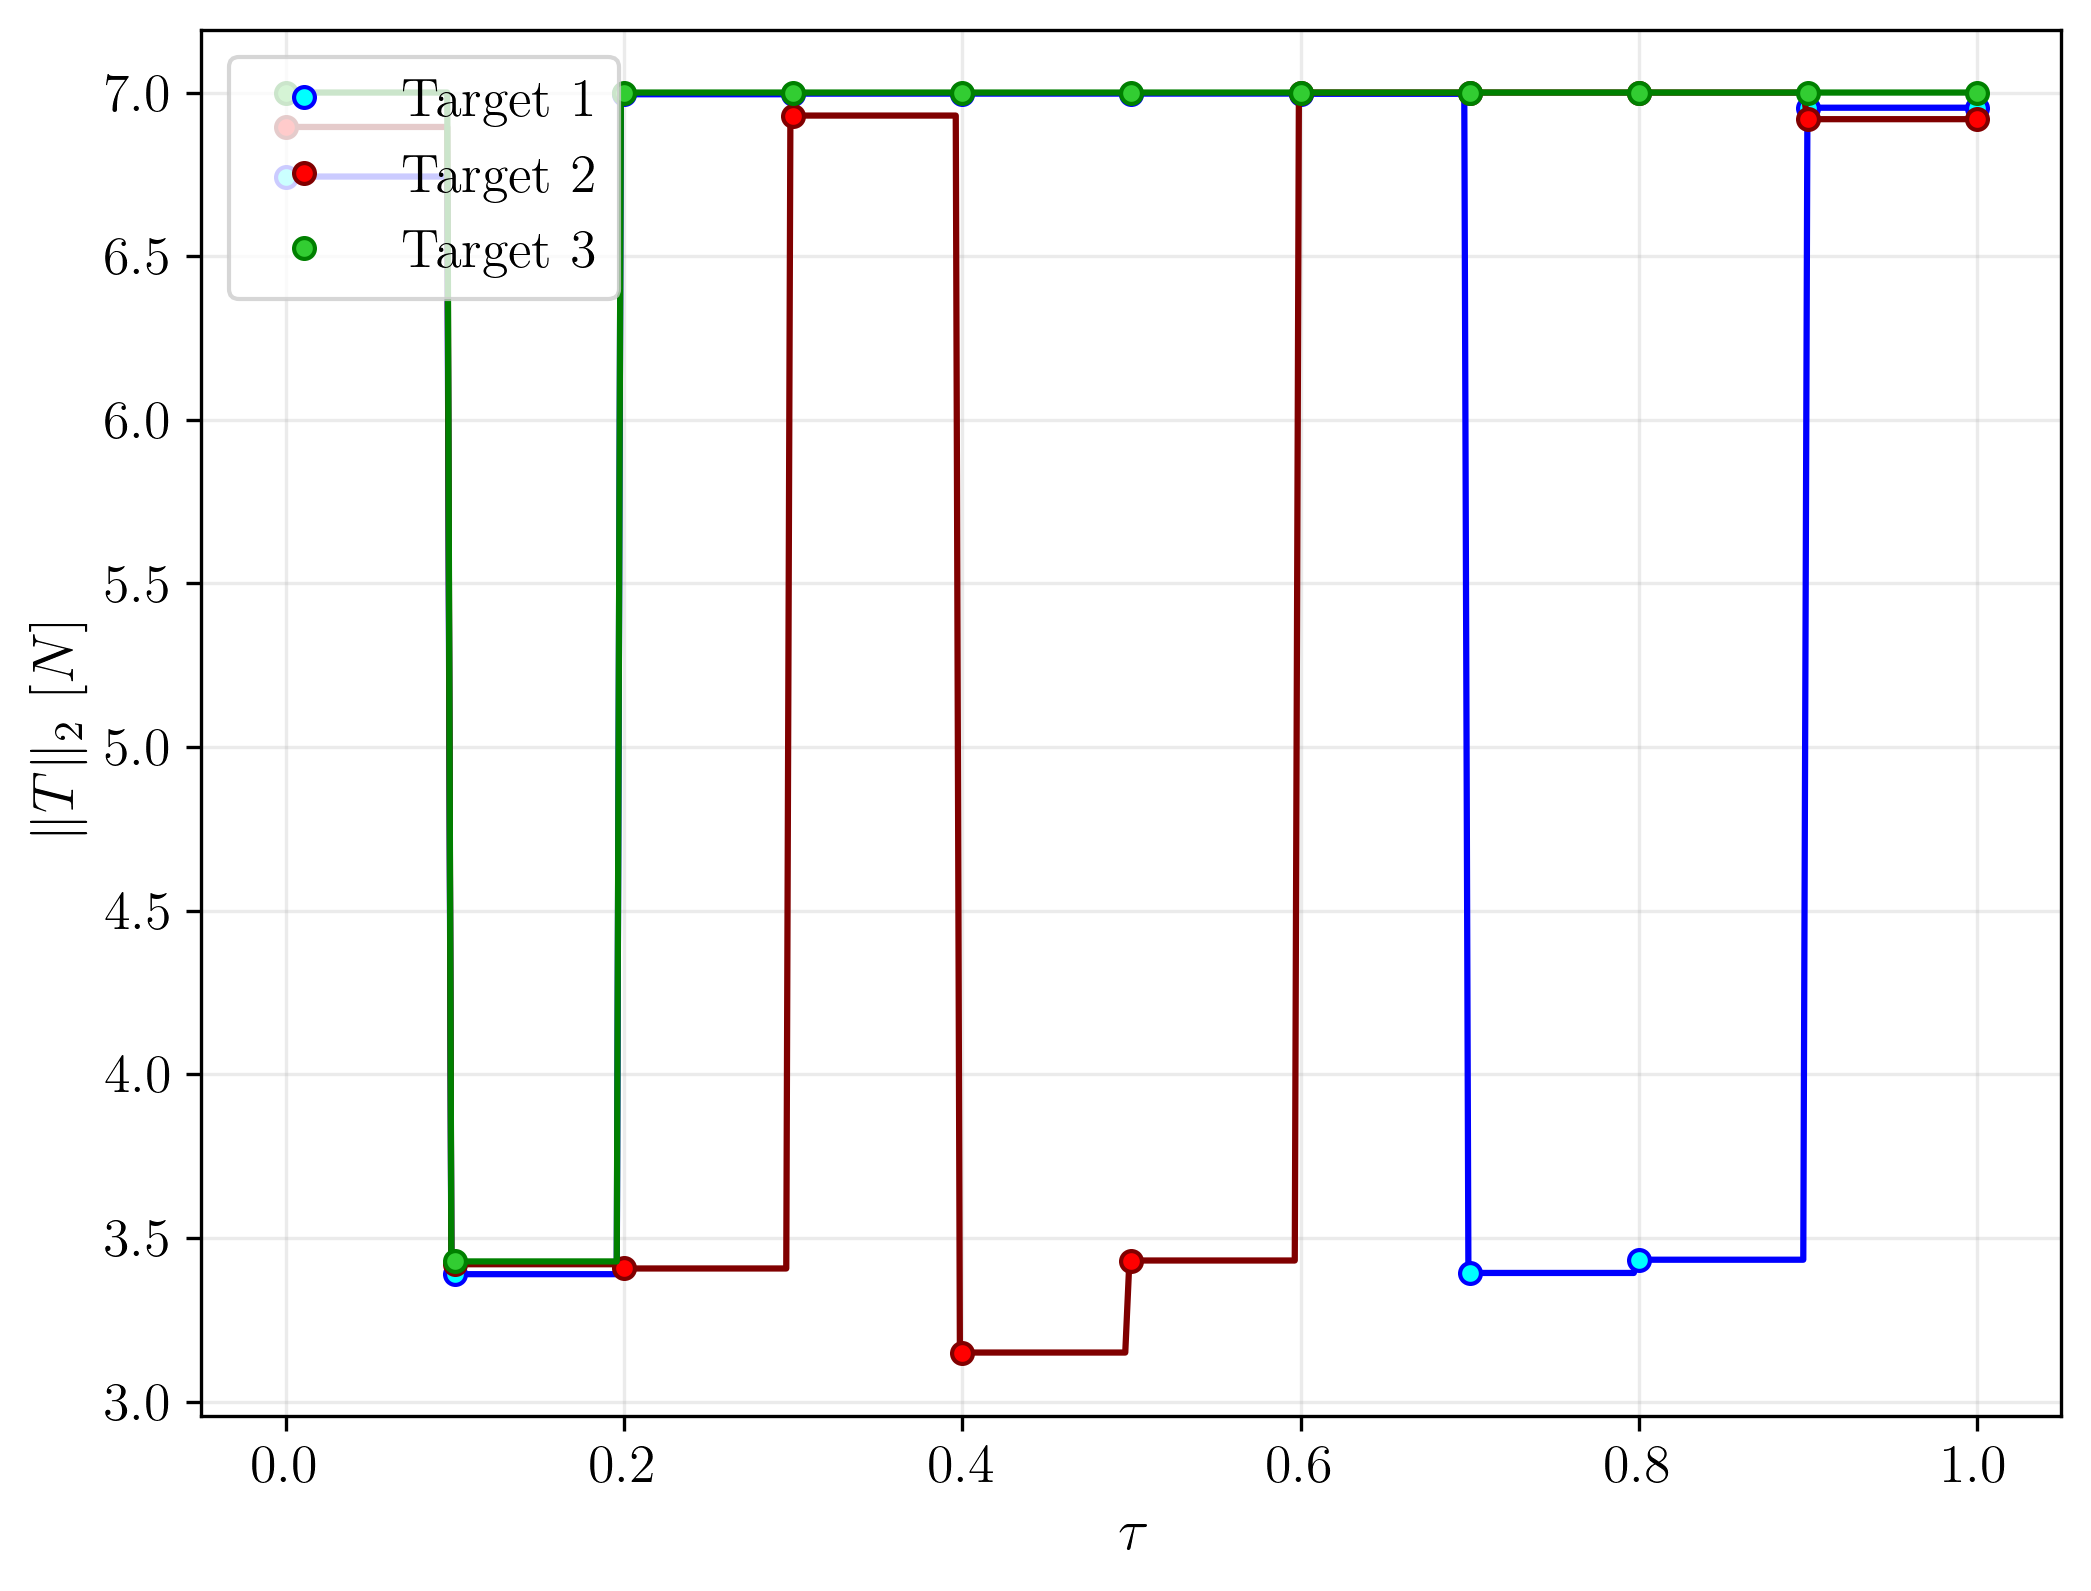

In [374]:
plot_thrust_magnitude(
    params, 
    scp_solutions, 
    scp_simulations;
    fname="plot_thrust_magnitude")
gcf()

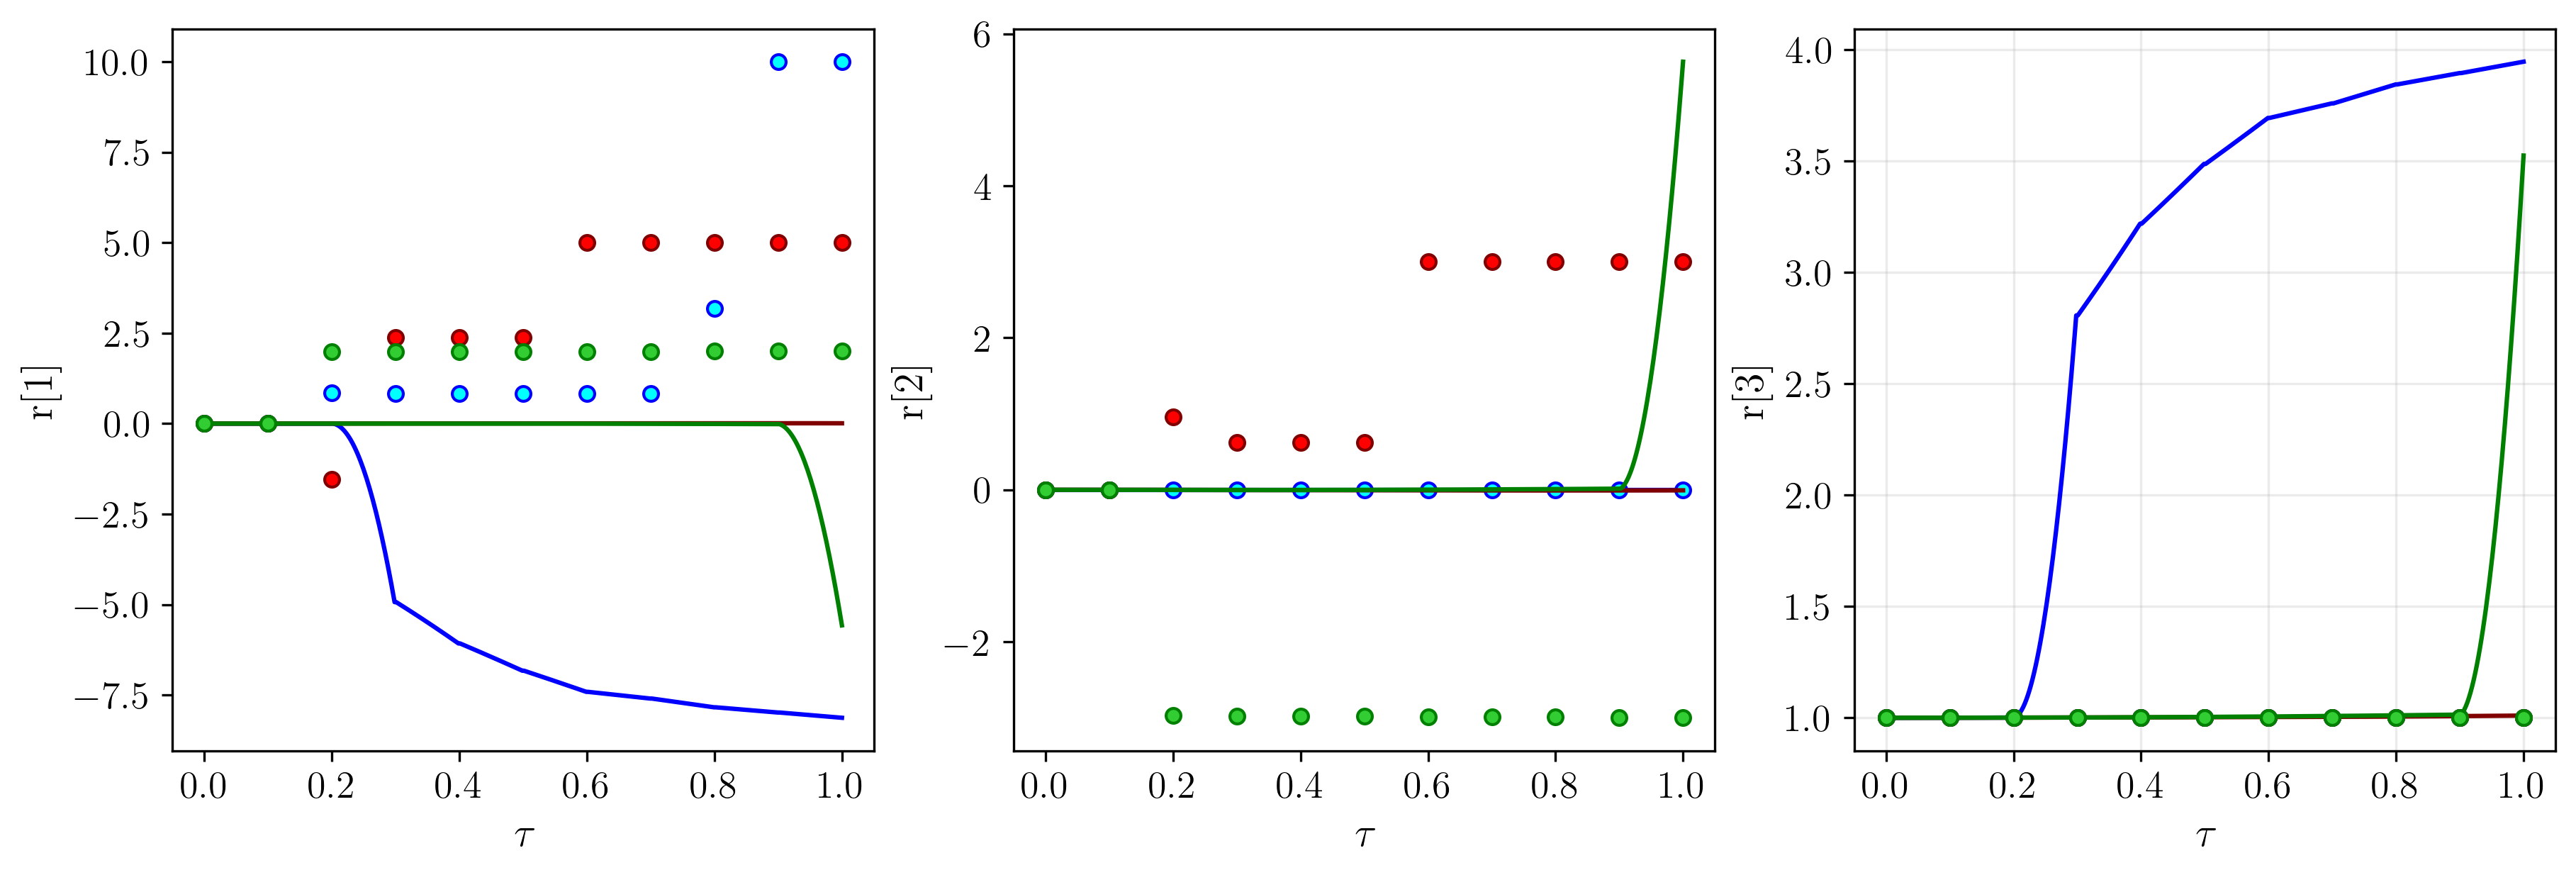

In [375]:
plot_3vec(
    params, 
    scp_solutions, 
    scp_simulations,
    "r";
    fname="plot_positions")
gcf()

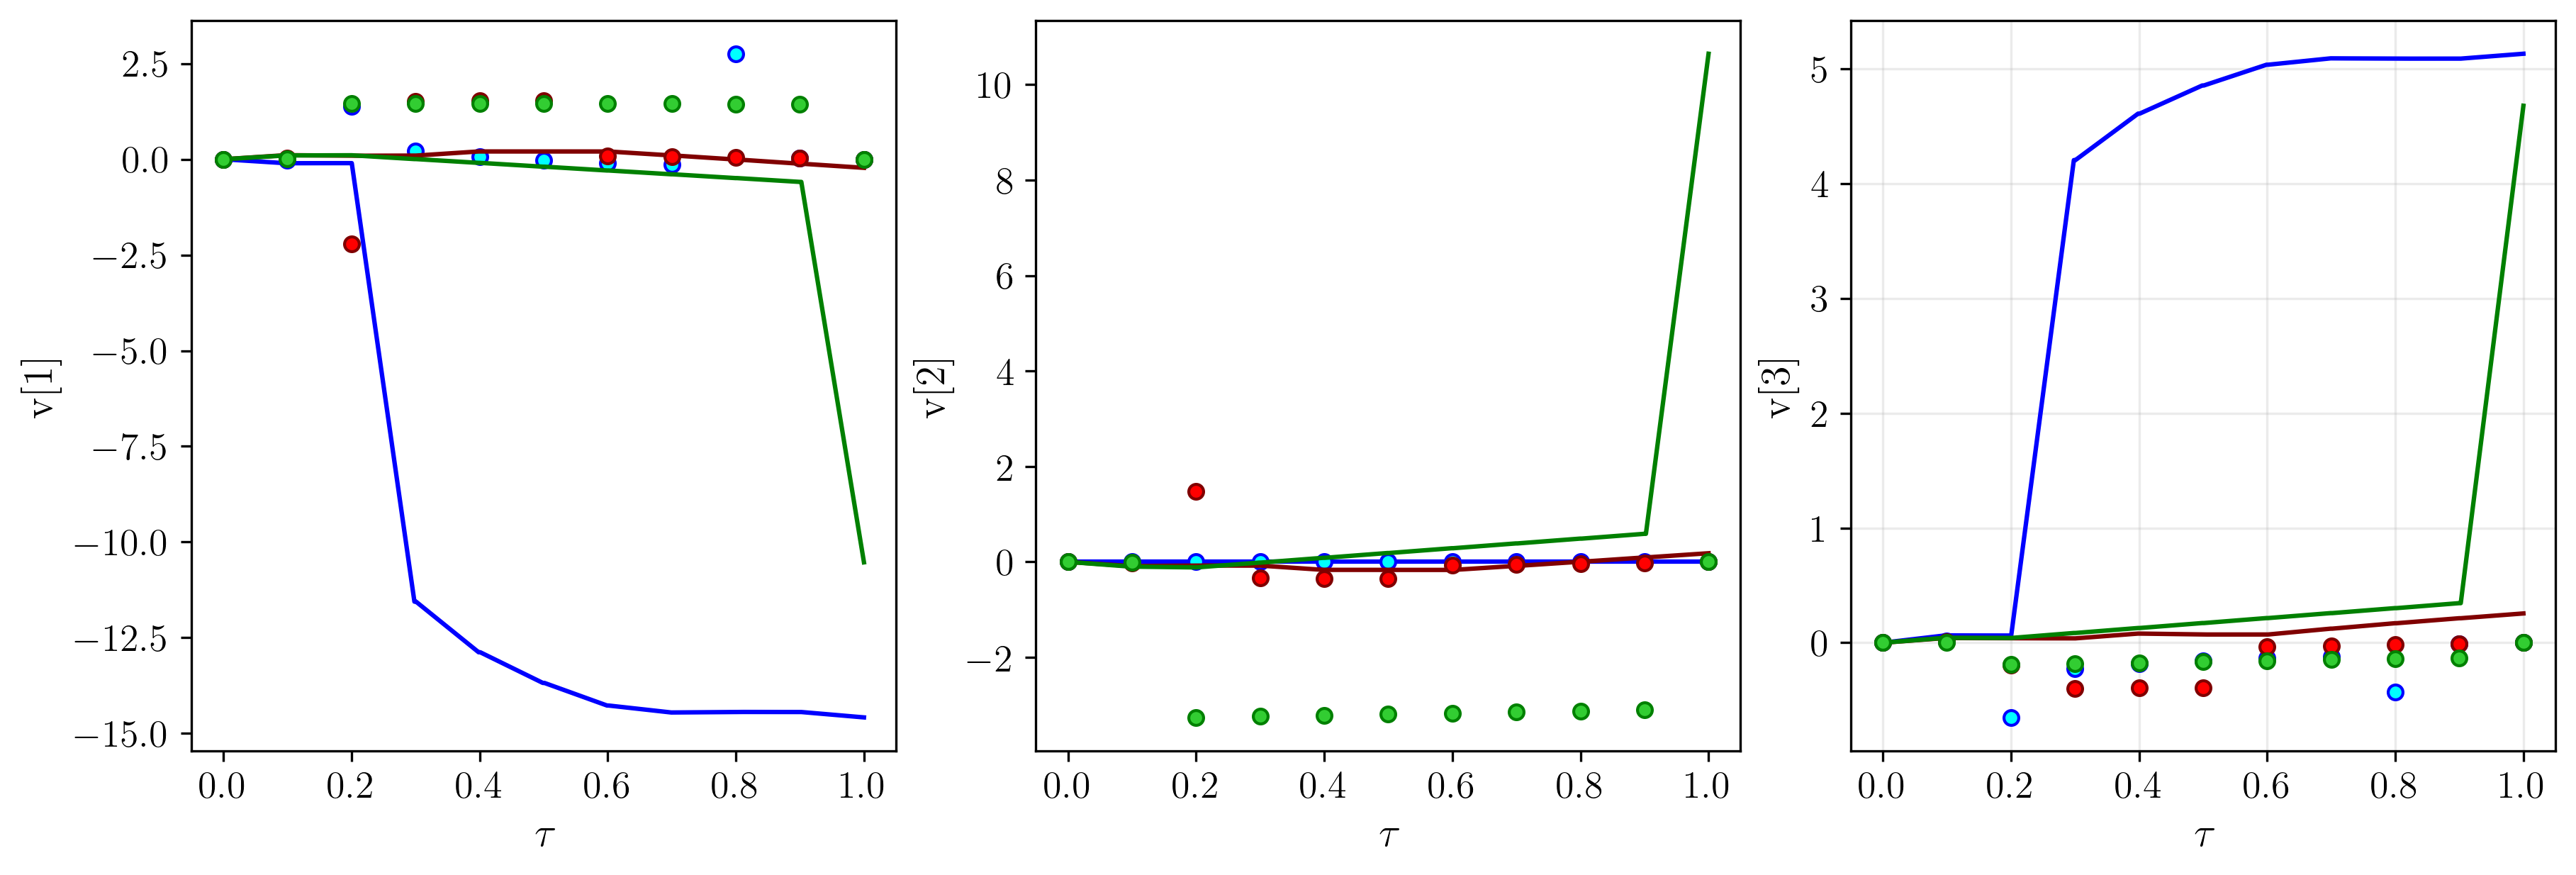

In [376]:
plot_3vec(
    params, 
    scp_solutions, 
    scp_simulations,
    "v";
    fname="temp")
gcf()

#### DDTO Plots

In [377]:
plot_parametric_trajectories(
    params, 
    ddtoscp_solutions, 
    ddtoscp_simulations;
    display_obstacles=true,
    fname="ddtoscp_solutions")
gcf()

UndefVarError: UndefVarError: ddtoscp_solutions not defined